In [1]:
# Importing Necessary Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
# Loading both datasets
df1 = pd.read_csv('diabetes.csv')
df2 = pd.read_csv('indian_diabetes_synthetic_100k.csv')
df = pd.concat([df1, df2], ignore_index=True)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [13]:
# Data Inspection and statistical summary
df.isna().sum()
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,100768.000000,100768.000000,100768.000000,100768.000000,100768.000000,100768.000000,100768.000000,100768.000000,100768.000000
mean,2.454718,113.176276,77.405228,27.523073,67.222541,27.311425,0.499253,35.487982,0.303291
std,2.342538,33.310100,12.043445,9.925014,64.107922,5.545445,0.348528,9.456015,0.459682
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,88.000000,69.000000,21.000000,24.000000,23.500000,0.262000,29.000000,0.000000
50%,2.000000,107.000000,77.000000,27.000000,49.000000,27.300000,0.406000,34.000000,0.000000
75%,4.000000,137.000000,86.000000,34.000000,90.000000,31.000000,0.630000,40.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [14]:
# Replace Zero values in important features with median value
df['Glucose'] = df['Glucose'].replace(0, np.median(df['Glucose']))

df['BloodPressure'] = df['BloodPressure'].replace(0, np.median(df['BloodPressure']))

df['SkinThickness'] = df['SkinThickness'].replace(0, np.median(df['SkinThickness']))

df['Insulin'] = df['Insulin'].replace(0, np.median(df['Insulin']))

df['BMI'] = df['BMI'].replace(0, np.median(df['BMI']))

In [15]:
# Feature and Target Separation
X = df.drop(columns=['Outcome'])
y = df['Outcome']

In [23]:
from sklearn.model_selection import train_test_split
pima = pd.read_csv('diabetes.csv')
X_real = pima.drop('Outcome', axis=1)
y_real = pima['Outcome']
X_train_r, X_test, y_train_r, y_test = train_test_split(
    X_real, y_real, test_size=0.2, random_state=42, stratify=y_real)
synth = pd.read_csv('indian_diabetes_synthetic_100k.csv')
synth_sample = synth.sample(n=3000, random_state=42)
X_train = pd.concat([X_train_r, synth_sample.drop('Outcome', axis=1)])
y_train = pd.concat([y_train_r, synth_sample['Outcome']])

In [24]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
# Logistic Regression Model Training
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [26]:
# Model Prediction and evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred = model.predict(X_test_scaled)
print("Accuracy of this model:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy of this model: 0.7012987012987013
              precision    recall  f1-score   support

           0       0.79      0.74      0.76       100
           1       0.57      0.63      0.60        54

    accuracy                           0.70       154
   macro avg       0.68      0.68      0.68       154
weighted avg       0.71      0.70      0.70       154



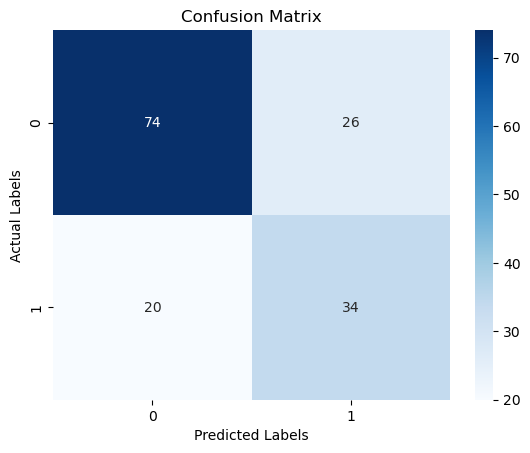

In [27]:
# Confusion Matrix Visualisation
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.show()

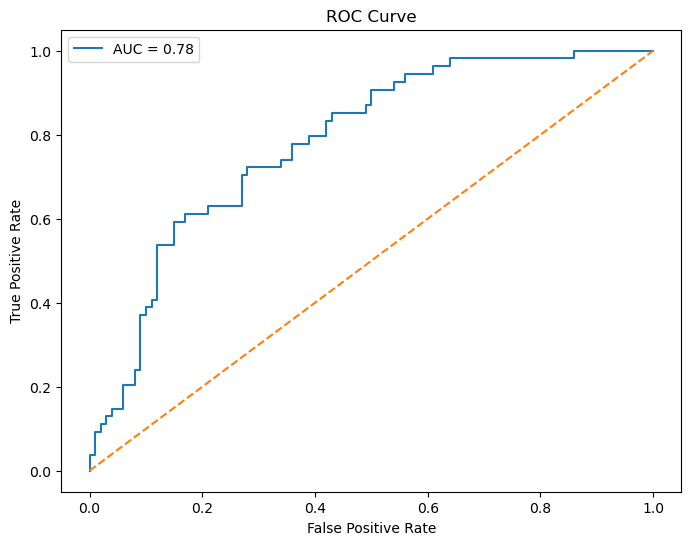

In [28]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()